# Q1 — Part 1: Stylised Facts of the Equal-Weight Portfolio

**SMM272 Risk Analysis**

Covers:
1. Data loading and return computation  
2. Descriptive statistics  
3. Normality tests (Jarque-Bera, KS, Shapiro-Wilk, Anderson-Darling)  
4. Autocorrelation and ARCH-LM tests  
5. Rolling volatility and mean (6-month / 126-day window)  
6. Figures for the report

In [12]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')


# Load data (prices of NVDA, AAPL, MSFT, IBM, GOOGL, AMZN)
prices = pd.read_excel('price_data.xlsx', index_col=0)
N = len(prices.columns)
# Compute log returns
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.columns = ['AAPL_RET', 'MSFT_RET', 'IBM_RET', 'NVDA_RET', 'GOOGL_RET', 'AMZN_RET']
# Portfolio weights
weights = np.array([1/N for i in range(N)])
# Portfolio returns
ret_portfolio = log_returns.dot(weights)
# Save Portfolio returns data to a CSV file
ret_portfolio.to_csv('portfolio_returns.csv', header=True)


# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

DARK  = '#1C1C1C'
RED   = '#C0392B'
BLUE  = '#2471A3'
GOLD  = '#B7950B'
GREEN = '#1E8449'

In [13]:
r     = ret_portfolio.dropna().values
dates = ret_portfolio.dropna().index

print(f"Sample : {dates[0].date()} to {dates[-1].date()}")
print(f"N      : {len(r):,}")

Sample : 2014-01-03 to 2025-12-31
N      : 2,997


## 1 · Descriptive Statistics

In [14]:
mean_r   = np.mean(r)
median_r = np.median(r)
std_r    = np.std(r, ddof=1)
skew_r   = stats.skew(r)
kurt_r   = stats.kurtosis(r)          # excess kurtosis
min_r, max_r = r.min(), r.max()
ann_ret  = mean_r * 252
ann_vol  = std_r  * np.sqrt(252)

# Empirical tail percentiles
pct_1  = np.percentile(r, 1)
pct_99 = np.percentile(r, 99)

# Cumulative return and drawdown
wealth      = np.cumprod(1 + r)
cum_ret     = wealth - 1
rolling_max = np.maximum.accumulate(wealth)
drawdown    = (wealth - rolling_max) / rolling_max
max_dd      = drawdown.min()

rows = {
    'Annualised mean return':   f'{ann_ret*100:.2f}%',
    'Annualised volatility':    f'{ann_vol*100:.2f}%',
    'Sharpe ratio (rf = 0)':    f'{ann_ret/ann_vol:.4f}',
    'Daily mean':               f'{mean_r:.6f}',
    'Daily median':             f'{median_r:.6f}',
    'Daily std dev':            f'{std_r:.6f}',
    'Skewness':                 f'{skew_r:.4f}',
    'Excess kurtosis':          f'{kurt_r:.4f}',
    'Min (daily)':              f'{min_r:.4f}',
    'Max (daily)':              f'{max_r:.4f}',
    'Empirical 1st pct':        f'{pct_1:.4f}',
    'Empirical 99th pct':       f'{pct_99:.4f}',
    'Gaussian 1st pct':         f'{stats.norm.ppf(0.01, mean_r, std_r):.4f}',
    'Max drawdown':             f'{max_dd*100:.2f}%',
}

print(f"{'Statistic':<35} {'Value':>12}")
print('-' * 49)
for k, v in rows.items():
    print(f"{k:<35} {v:>12}")

Statistic                                  Value
-------------------------------------------------
Annualised mean return                    24.66%
Annualised volatility                     23.99%
Sharpe ratio (rf = 0)                     1.0281
Daily mean                              0.000979
Daily median                            0.001479
Daily std dev                           0.015113
Skewness                                 -0.3365
Excess kurtosis                           6.3438
Min (daily)                              -0.1276
Max (daily)                               0.1132
Empirical 1st pct                        -0.0437
Empirical 99th pct                        0.0376
Gaussian 1st pct                         -0.0342
Max drawdown                             -40.02%


## 2 · Normality Tests

In [15]:
jb_stat, jb_pval = stats.jarque_bera(r)
ks_stat, ks_pval = stats.kstest(r, 'norm', args=(mean_r, std_r))
sw_stat, sw_pval = stats.shapiro(r[:5000])   # Shapiro-Wilk limited to 5,000 obs
ad_result        = stats.anderson(r, dist='norm')

print(f"{'Test':<20} {'Statistic':>12}  {'p-value':>10}  {'Decision'}")
print('-' * 65)
print(f"{'Jarque-Bera':<20} {jb_stat:>12.2f}  {jb_pval:>10.2e}  Reject H0 (normality)")
print(f"{'KS':<20} {ks_stat:>12.4f}  {ks_pval:>10.4f}  Reject H0")
print(f"{'Shapiro-Wilk':<20} {sw_stat:>12.4f}  {sw_pval:>10.4e}  Reject H0")
print(f"{'Anderson-Darling':<20} {ad_result.statistic:>12.4f}  {'—':>10}  Reject at all levels")

# Tail comparison
gauss_pct1 = stats.norm.ppf(0.01, mean_r, std_r)
print(f"\nEmpirical 1st pct : {pct_1:.4f}")
print(f"Gaussian 1st pct  : {gauss_pct1:.4f}")
print(f"Underestimate      : {(pct_1 - gauss_pct1)/abs(gauss_pct1)*100:.1f}%  "
      f"(Gaussian understates tail loss)")

Test                    Statistic     p-value  Decision
-----------------------------------------------------------------
Jarque-Bera               5082.02    0.00e+00  Reject H0 (normality)
KS                         0.0807      0.0000  Reject H0
Shapiro-Wilk               0.9364  5.0303e-34  Reject H0
Anderson-Darling          36.5601           —  Reject at all levels

Empirical 1st pct : -0.0437
Gaussian 1st pct  : -0.0342
Underestimate      : -27.8%  (Gaussian understates tail loss)


## 3 · Autocorrelation and ARCH Tests

In [16]:
def ljung_box(x, lags=20):
    T = len(x)
    acf_vals = [np.corrcoef(x[:-k], x[k:])[0, 1] for k in range(1, lags + 1)]
    lb_stat  = T * (T + 2) * sum(rho**2 / (T - k)
                                  for k, rho in enumerate(acf_vals, start=1))
    p_val    = 1 - stats.chi2.cdf(lb_stat, df=lags)
    return lb_stat, p_val, acf_vals

def arch_test(x, lags=10):
    T = len(x)
    resid2 = x**2
    Y = resid2[lags:]
    X = np.column_stack([resid2[lags - k - 1: T - k - 1] for k in range(lags)])
    X = np.column_stack([np.ones(len(Y)), X])
    beta  = np.linalg.lstsq(X, Y, rcond=None)[0]
    Y_hat = X @ beta
    ss_res = np.sum((Y - Y_hat)**2)
    ss_tot = np.sum((Y - Y.mean())**2)
    r2     = 1 - ss_res / ss_tot
    lm_stat = len(Y) * r2
    p_val   = 1 - stats.chi2.cdf(lm_stat, df=lags)
    return lm_stat, p_val

lb_stat_r,  lb_pval_r,  acf_r  = ljung_box(r,    lags=20)
lb_stat_r2, lb_pval_r2, acf_r2 = ljung_box(r**2, lags=20)
arch_stat,  arch_pval          = arch_test(r, lags=10)

print(f"{'Test':<35} {'Statistic':>10}  {'p-value':>10}  Decision")
print('-' * 75)
print(f"{'Ljung-Box (returns, 20 lags)':<35} {lb_stat_r:>10.2f}  {lb_pval_r:>10.4f}  "
      f"{'Serial correlation' if lb_pval_r < 0.05 else 'No serial corr.'}")
print(f"{'Ljung-Box (squared ret., 20 lags)':<35} {lb_stat_r2:>10.2f}  {lb_pval_r2:>10.4f}  "
      f"{'Volatility clustering' if lb_pval_r2 < 0.05 else 'No clustering'}")
print(f"{'ARCH-LM (10 lags)':<35} {arch_stat:>10.2f}  {arch_pval:>10.4e}  "
      f"{'ARCH effects' if arch_pval < 0.05 else 'No ARCH effects'}")

Test                                 Statistic     p-value  Decision
---------------------------------------------------------------------------
Ljung-Box (returns, 20 lags)            137.22      0.0000  Serial correlation
Ljung-Box (squared ret., 20 lags)      2160.45      0.0000  Volatility clustering
ARCH-LM (10 lags)                       604.39  0.0000e+00  ARCH effects


## 4 · Rolling Statistics (6-month / 125-day window)

In [17]:
window    = 125    # ~6 months
roll_vol  = pd.Series(r, index=dates).rolling(window).std()  * np.sqrt(252)
roll_mean = pd.Series(r, index=dates).rolling(window).mean() * 252

## 5 · Figures

Each figure is saved as a separate file for insertion into the report.

| # | File | Content |
|---|------|---------|
| 1 | `fig1_cumulative_return.png` | Cumulative portfolio return with max-drawdown annotation |
| 2 | `fig2_daily_returns.png` | Daily return bar chart |
| 3 | `fig3_return_distribution.png` | Empirical vs Normal density |
| 4 | `fig4_qq_plot.png` | Normal Q-Q plot |
| 5 | `fig5_acf_returns.png` | ACF of returns |
| 6 | `fig6_acf_squared.png` | ACF of squared returns (volatility clustering) |
| 7 | `fig7_rolling_volatility.png` | Rolling annualised volatility (6-month window) |
| 8 | `fig8_rolling_mean.png` | Rolling annualised mean return (6-month window) |

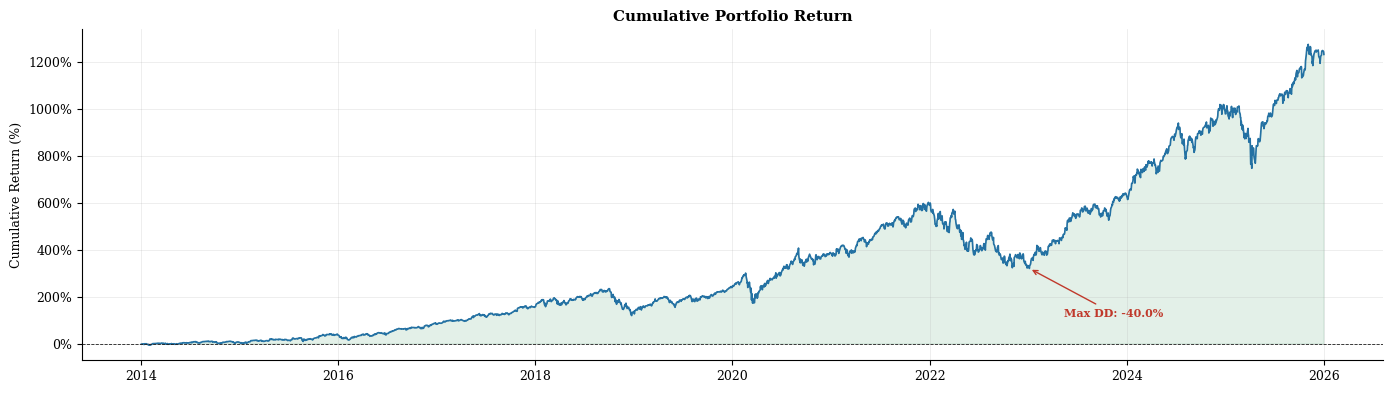

Saved: fig1_cumulative_return.png


In [18]:
# ── Figure 1: Cumulative Return ──────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 4), facecolor='white')
ax1.plot(dates, cum_ret * 100, color=BLUE, lw=1.2)
ax1.fill_between(dates, cum_ret * 100, 0, where=(cum_ret >= 0), alpha=0.12, color=GREEN)
ax1.fill_between(dates, cum_ret * 100, 0, where=(cum_ret < 0),  alpha=0.12, color=RED)
ax1.axhline(0, color=DARK, lw=0.6, ls='--')
ax1.set_title('Cumulative Portfolio Return', fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
dd_idx = np.argmin(drawdown)
ax1.annotate(f'Max DD: {max_dd*100:.1f}%',
             xy=(dates[dd_idx], cum_ret[dd_idx] * 100),
             xytext=(25, -35), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color=RED),
             color=RED, fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_cumulative_return.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig1_cumulative_return.png')

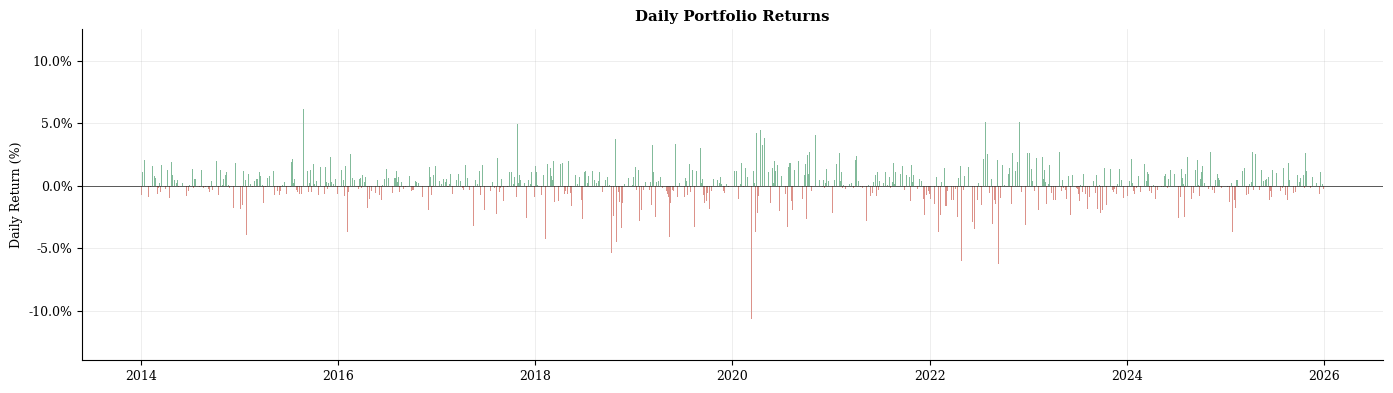

Saved: fig2_daily_returns.png


In [19]:
# ── Figure 2: Daily Returns ───────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 4), facecolor='white')
ax2.bar(dates, r * 100, color=np.where(r >= 0, GREEN, RED), alpha=0.55, width=0.8)
ax2.axhline(0, color=DARK, lw=0.5)
ax2.set_title('Daily Portfolio Returns', fontweight='bold')
ax2.set_ylabel('Daily Return (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.savefig('fig2_daily_returns.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig2_daily_returns.png')

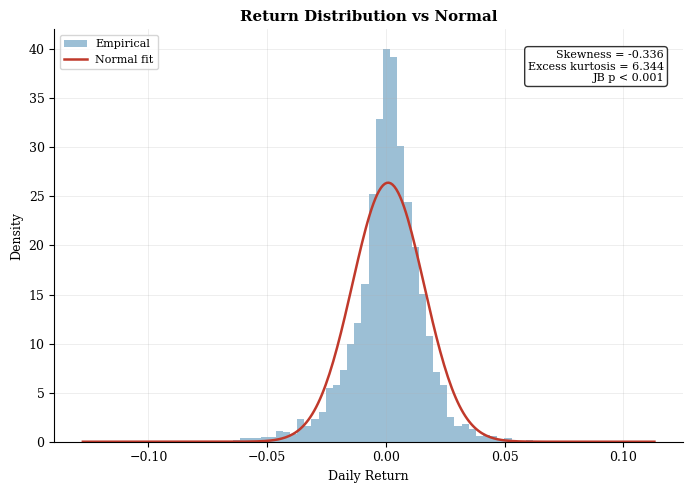

Saved: fig3_return_distribution.png


In [20]:
# ── Figure 3: Return Distribution vs Normal ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 5), facecolor='white')
x_range    = np.linspace(r.min(), r.max(), 300)
normal_pdf = stats.norm.pdf(x_range, mean_r, std_r)
ax3.hist(r, bins=80, density=True, color=BLUE, alpha=0.45, label='Empirical')
ax3.plot(x_range, normal_pdf, color=RED, lw=1.8, label='Normal fit')
ax3.set_title('Return Distribution vs Normal', fontweight='bold')
ax3.set_xlabel('Daily Return')
ax3.set_ylabel('Density')
ax3.legend(fontsize=8)
ax3.text(0.97, 0.95,
         f'Skewness = {skew_r:.3f}\nExcess kurtosis = {kurt_r:.3f}\nJB p < 0.001',
         transform=ax3.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('fig3_return_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig3_return_distribution.png')

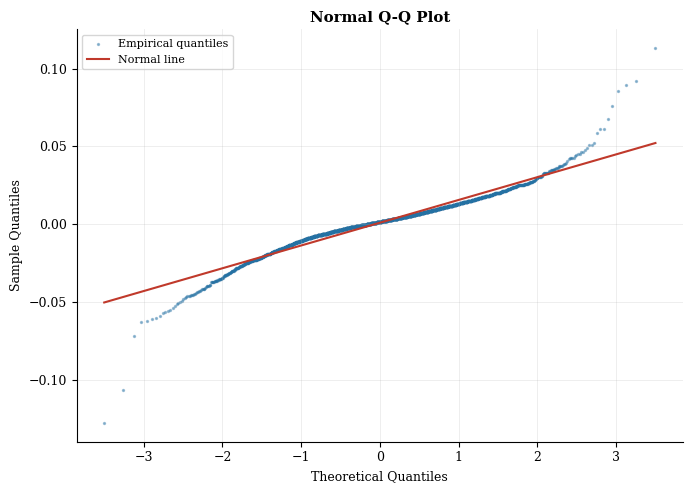

Saved: fig4_qq_plot.png


In [21]:
# ── Figure 4: Normal Q-Q Plot ─────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(7, 5), facecolor='white')
(osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
ax4.scatter(osm, osr, s=2, color=BLUE, alpha=0.4, label='Empirical quantiles')
ax4.plot(osm, slope * np.array(osm) + intercept, color=RED, lw=1.5, label='Normal line')
ax4.set_title('Normal Q-Q Plot', fontweight='bold')
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Sample Quantiles')
ax4.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig4_qq_plot.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig4_qq_plot.png')

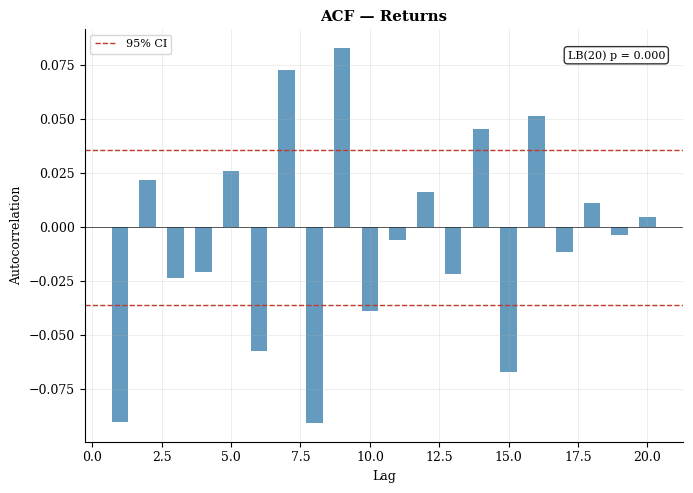

Saved: fig5_acf_returns.png


In [22]:
# ── Figure 5: ACF of Returns ──────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(7, 5), facecolor='white')
lags_plot = np.arange(1, 21)
conf      = 1.96 / np.sqrt(len(r))
ax5.bar(lags_plot, acf_r, color=BLUE, alpha=0.7, width=0.6)
ax5.axhline( conf, color=RED, lw=1, ls='--', label='95% CI')
ax5.axhline(-conf, color=RED, lw=1, ls='--')
ax5.axhline(0, color=DARK, lw=0.5)
ax5.set_title('ACF — Returns', fontweight='bold')
ax5.set_xlabel('Lag')
ax5.set_ylabel('Autocorrelation')
ax5.legend(fontsize=8)
ax5.text(0.97, 0.95, f'LB(20) p = {lb_pval_r:.3f}',
         transform=ax5.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('fig5_acf_returns.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig5_acf_returns.png')

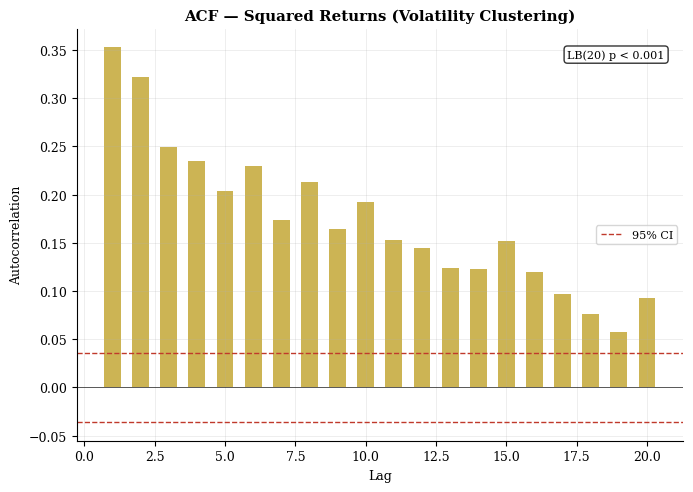

Saved: fig6_acf_squared.png


In [23]:
# ── Figure 6: ACF of Squared Returns ─────────────────────────────────────
fig6, ax6 = plt.subplots(figsize=(7, 5), facecolor='white')
ax6.bar(lags_plot, acf_r2, color=GOLD, alpha=0.7, width=0.6)
ax6.axhline( conf, color=RED, lw=1, ls='--', label='95% CI')
ax6.axhline(-conf, color=RED, lw=1, ls='--')
ax6.axhline(0, color=DARK, lw=0.5)
ax6.set_title('ACF — Squared Returns (Volatility Clustering)', fontweight='bold')
ax6.set_xlabel('Lag')
ax6.set_ylabel('Autocorrelation')
ax6.legend(fontsize=8)
ax6.text(0.97, 0.95, 'LB(20) p < 0.001',
         transform=ax6.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('fig6_acf_squared.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig6_acf_squared.png')

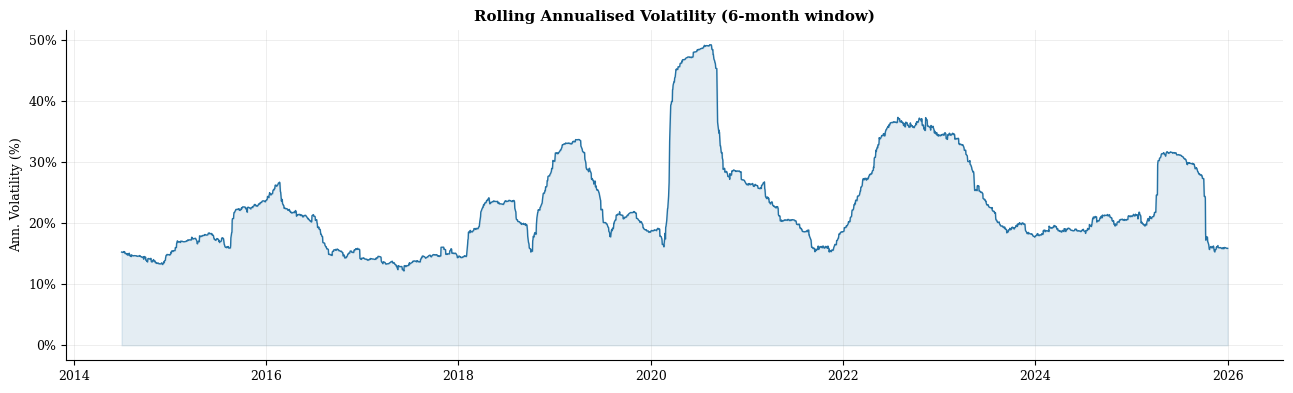

Saved: fig7_rolling_volatility.png


In [24]:
# ── Figure 7: Rolling Annualised Volatility (6-month / 125-day window) ───
fig7, ax7 = plt.subplots(figsize=(13, 4), facecolor='white')
ax7.plot(dates, roll_vol * 100, color=BLUE, lw=1.0)
ax7.fill_between(dates, roll_vol * 100, alpha=0.12, color=BLUE)
ax7.set_ylabel('Ann. Volatility (%)')
ax7.set_title('Rolling Annualised Volatility (6-month window)', fontweight='bold')
ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('fig7_rolling_volatility.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig7_rolling_volatility.png')

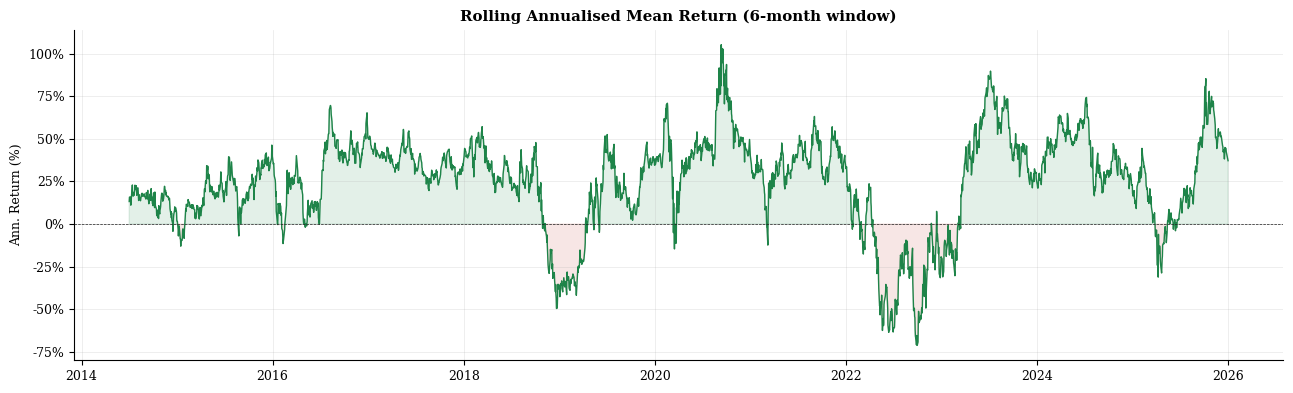

Saved: fig8_rolling_mean.png


In [25]:
# ── Figure 8: Rolling Annualised Mean Return (6-month / 125-day window) ──
fig8, ax8 = plt.subplots(figsize=(13, 4), facecolor='white')
ax8.plot(dates, roll_mean * 100, color=GREEN, lw=1.0)
ax8.fill_between(dates, roll_mean * 100, 0,
                 where=(roll_mean >= 0), alpha=0.12, color=GREEN)
ax8.fill_between(dates, roll_mean * 100, 0,
                 where=(roll_mean < 0),  alpha=0.12, color=RED)
ax8.axhline(0, color=DARK, lw=0.5, ls='--')
ax8.set_ylabel('Ann. Return (%)')
ax8.set_title('Rolling Annualised Mean Return (6-month window)', fontweight='bold')
ax8.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('fig8_rolling_mean.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig8_rolling_mean.png')